# Time-dependent optimisers

The [previous example](04_Time_Dependent_Constraints.md) varied *inputs* of one optimiser over
the folds of a cross-validation scheme. This one varies the **optimiser itself**: a
`TimeDependent` whose per-fold values are whole optimisers is a *schedule of
optimisers*, and it works in two positions:

 1. **As the optimiser** — handed straight to `cross_val_predict`; fold `i` runs
    entry `i`.
 2. **In an optimiser-valued field** — a fallback (`fb`), a meta-optimiser's inner/outer
    optimisers, or a `Pipeline`'s optimisation step.

The admissibility rule is the same one that governs every other field: an input may be
time-dependent **iff it is problem definition** (what is being solved — and *which strategy
solves it* is problem definition), never **execution control** (solvers, random number
generators, a meta's own cross-validation scheme). The one wrinkle optimiser positions add is
that they are *required*: there is no static default to fall back to outside fold loops, so a
schedule there must state its fold-less value explicitly via `default`, or fold-less use
throws.

Our running subject is a **regime-switching backtest**: a defensive strategy in turbulent
markets, an aggressive one in calm markets, switched per rebalance.

In [1]:
using PortfolioOptimisers, PrettyTables
# Format for pretty tables.
resfmt = (v, i, j) -> begin
    if j == 1
        return v
    else
        return isa(v, Number) ? "$(round(v*100, digits=2)) %" : v
    end
end;

## 1. Setting up

Three years of daily data, and two `MeanRisk` strategies that are easy to tell apart: the
*defensive* one minimises variance under a 10 % position cap, the *aggressive* one maximises
the return–risk ratio uncapped. A walk-forward with a one-year training window rebalancing
every half-year gives us the fold loop.

In [2]:
using CSV, TimeSeries, DataFrames, Clarabel, Statistics, StableRNGs

X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252 * 3):end]
rd = prices_to_returns(X)

slv = [Solver(; name = :clarabel1, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false),
              check_sol = (; allow_local = true, allow_almost = true)),
       Solver(; name = :clarabel2, solver = Clarabel.Optimizer,
              settings = Dict("verbose" => false, "max_step_fraction" => 0.9),
              check_sol = (; allow_local = true, allow_almost = true))];

defensive = MeanRisk(; obj = MinimumRisk(),
                     opt = JuMPOptimiser(; slv = slv,
                                         wb = WeightBounds(; lb = 0.0, ub = 0.1)))
aggressive = MeanRisk(; obj = MaximumRatio(), opt = JuMPOptimiser(; slv = slv))

wf = IndexWalkForward(252, 126)
n = n_splits(wf, rd)

4

To read off *which* strategy a fold ran, we backtest both static strategies once and match
weights — a fold of the schedule that solves the same problem on the same window produces the
same weights.

In [3]:
pred_def = cross_val_predict(defensive, rd, wf)
pred_agg = cross_val_predict(aggressive, rd, wf)

function which_strategy(pred, i)
    w = pred.pred[i].res.w
    return if isapprox(w, pred_def.pred[i].res.w; rtol = 1e-6)
        "defensive"
    elseif isapprox(w, pred_agg.pred[i].res.w; rtol = 1e-6)
        "aggressive"
    else
        "other"
    end
end;

## 2. A schedule of optimisers as the optimiser

The simplest spelling is a per-fold vector of optimisers handed to `cross_val_predict`
*directly* — the schedule **is** the optimiser argument. Here the strategy alternates by
calendar: entry `i` is the complete optimiser for fold `i`, exactly as a constraint schedule's
entry `i` was the complete field value.

In [4]:
calendar = TimeDependent([isodd(i) ? defensive : aggressive for i in 1:n])
pred_cal = cross_val_predict(calendar, rd, wf)

pretty_table(DataFrame(:fold => 1:n, :ran => [which_strategy(pred_cal, i) for i in 1:n],
                       :max_weight => [maximum(p.res.w) for p in pred_cal.pred]);
             formatters = [resfmt])

┌───────┬────────────┬────────────┐
│  fold │        ran │ max_weight │
│ Int64 │     String │    Float64 │
├───────┼────────────┼────────────┤
│     1 │  defensive │     10.0 % │
│     2 │ aggressive │     16.9 % │
│     3 │  defensive │     10.0 % │
│     4 │ aggressive │    28.87 % │
└───────┴────────────┴────────────┘


Odd folds are position-capped minimum-variance solutions, even folds concentrate freely —
each fold ran its own strategy, and everything downstream of the fold loop (previous-weights
threading, prediction stitching, plotting) is oblivious to the switch.

Like any schedule, it is sized to the consuming loop's folds and validated at `split` time:

In [5]:
try
    cross_val_predict(TimeDependent([defensive, aggressive]), rd, wf)
catch err
    err
end

DimensionMismatch("a TimeDependent schedule of optimisers has 2 entries, which must equal the number of folds (4)")

## 3. Fold-less solves: `default` or throw

A constraint schedule is inert outside fold loops because the field it sits in has a *static
default* to reset to. An optimiser position has none — "no optimiser" is not a thing
`optimise` can run — so a fold-less solve of a defaultless schedule fails, with a structured
error pointing at `cross_val_predict`:

In [6]:
try
    optimise(calendar, rd)
catch err
    err
end

TimeDependentDefaultError{String}("a TimeDependent schedule stands in for the optimiser itself but supplies no `default`, so there is no optimiser to run outside a fold loop. A schedule is defined only over the folds of a cross-validation scheme; this solve has none. Give the schedule a fold-less optimiser: TimeDependent(val; default = opt).")

The schedule states its fold-less value with the `default` keyword. This is deliberately
explicit — entry 1 is a statement about fold 1, not about fold-less use, so the library never
silently promotes it:

In [7]:
calendar_d = TimeDependent([isodd(i) ? defensive : aggressive for i in 1:n];
                           default = defensive)
res_foldless = optimise(calendar_d, rd)
isapprox(res_foldless.w, optimise(defensive, rd).w)

true

The `default` never runs inside a fold loop, so it is *not* counted by the fold-count
assertion — only `val`'s entries are.

## 4. Regime switching with callables

A calendar fixed in advance is rarely the point. A **callable** schedule derives the fold's
optimiser from the fold's own data: this one compares the training window's annualised
equal-weight volatility against the full sample's and goes defensive in the turbulent half.

In [8]:
function ew_vol(Xm)
    return std(Xm * fill(1 / size(Xm, 2), size(Xm, 2))) * sqrt(252)
end
function regime(ctx)
    vol_train = ew_vol(ctx.rd.X[ctx.train_idx[ctx.i], :])
    return vol_train > ew_vol(ctx.rd.X) ? defensive : aggressive
end
pred_regime = cross_val_predict(TimeDependent(regime; default = defensive), rd, wf)

pretty_table(DataFrame(:fold => 1:n, :ran => [which_strategy(pred_regime, i) for i in 1:n]);
             formatters = [resfmt])

┌───────┬────────────┐
│  fold │        ran │
│ Int64 │     String │
├───────┼────────────┤
│     1 │  defensive │
│     2 │ aggressive │
│     3 │ aggressive │
│     4 │ aggressive │
└───────┴────────────┘


Because a bare function's output type is unknowable upfront, it is checked when the fold loop
swaps the value in — a callable that returns something that is not an optimiser fails there,
with the fold that exposed it:

In [9]:
try
    cross_val_predict(TimeDependent(ctx -> Fees(; l = 0.001); default = defensive), rd, wf)
catch err
    err
end

ArgumentError("a TimeDependent schedule in an optimiser position resolved to a Fees{Nothing, Float64, Nothing, Nothing, Nothing, @NamedTuple{atol::Float64}}, which is neither an optimisation estimator nor a precomputed optimisation result. A callable schedule standing in for an optimiser must return an OptE_Opt for every fold.")

A struct subtyping `TimeDependentOptimiserCallable` declares its output kind *in the
type*, so a schedule holding one is statically admissible wherever the optimiser-typed bounds
require it (the meta-optimisers' fields below), its parameters are inspectable data, and —
being a type — it can declare previous-weights needs via `needs_previous_weights`.
Here is the same policy as a reusable type:

In [10]:
struct RegimeSwitch{T <: PortfolioOptimisers.OptimisationEstimator,
                    U <: PortfolioOptimisers.OptimisationEstimator} <:
       PortfolioOptimisers.TimeDependentOptimiserCallable
    calm::T
    turbulent::U
end
function (r::RegimeSwitch)(ctx::TimeDependentContext)
    vol_train = ew_vol(ctx.rd.X[ctx.train_idx[ctx.i], :])
    return vol_train > ew_vol(ctx.rd.X) ? r.turbulent : r.calm
end
pred_struct = cross_val_predict(TimeDependent(RegimeSwitch(aggressive, defensive);
                                              default = defensive), rd, wf)
all(isapprox(a.res.w, b.res.w) for (a, b) in zip(pred_struct.pred, pred_regime.pred))

true

How do the three backtests compare out of sample? The switcher sits where it should — its
realised risk between the two static strategies:

In [11]:
rk = LowOrderMoment(; alg = SecondMoment())
pretty_table(DataFrame(:strategy => ["defensive", "aggressive", "regime switch"],
                       :oos_risk =>
                           [expected_risk(rk, pred_def), expected_risk(rk, pred_agg),
                            expected_risk(rk, pred_regime)]); formatters = [resfmt])

┌───────────────┬──────────┐
│      strategy │ oos_risk │
│        String │  Float64 │
├───────────────┼──────────┤
│     defensive │   0.01 % │
│    aggressive │   0.02 % │
│ regime switch │   0.01 % │
└───────────────┴──────────┘


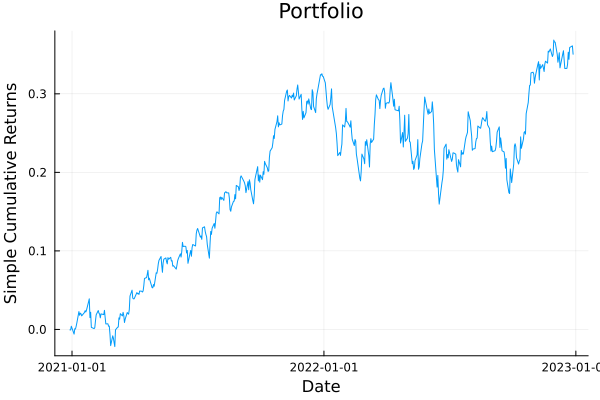

In [12]:
using StatsPlots, GraphRecipes
plot_ptf_cumulative_returns(pred_regime)

The composition plot makes the switching visible — capped, spread-out folds alternate with
concentrated ones:

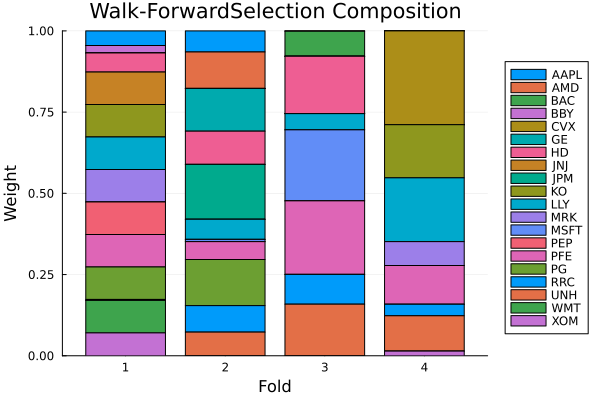

In [13]:
plot_composition(pred_regime)

## 5. Mixed schedules: estimators and precomputed results side by side

An entry need not be an estimator. A precomputed `OptimisationResult` is a legal
entry: its fold is *predict-only* — the stored weights are replayed on the fold's test window,
not re-optimised. This splices an externally solved period (a frozen model, a
committee-approved allocation) into an otherwise live backtest:

In [14]:
frozen = optimise(defensive, rd)
mixed = TimeDependent([i == 1 ? frozen : aggressive for i in 1:n]; default = defensive)
pred_mixed = cross_val_predict(mixed, rd, wf)
isapprox(pred_mixed.pred[1].res.w, frozen.w)

true

Fold 1 carries the frozen weights verbatim; the remaining folds re-optimise per window.

The one scheme mixed schedules cannot serve is asset-subsampling cross-validation
(`MultipleRandomised`): each path views the problem down to a random asset subset, and
a solved result has no sub-portfolio semantics — there is no meaningful "view" of a fixed
weight vector onto fewer assets — so result entries are rejected up front:

In [15]:
mrand = MultipleRandomised(IndexWalkForward(252, 126); subset_size = 15, n_subsets = 2,
                           rng = StableRNG(987654321), seed = 42)
try
    cross_val_predict(mixed, rd, mrand)
catch err
    err
end

ArgumentError("a precomputed optimisation result cannot be viewed to an asset subset: its weights were solved over the full universe and a sub-portfolio of them has no defined meaning. A TimeDependent schedule holding precomputed results is therefore incompatible with asset-subsampling cross-validation (e.g. MultipleRandomised); use estimator entries there instead.")

(A schedule of *estimators* works under `MultipleRandomised` exactly like any other
optimiser — estimator entries are viewed down to each path's subset like a static optimiser
would be.)

## 6. Post-swap recursion: entries with schedules of their own

The estimator a schedule swaps in may itself carry schedules in its fields. Those resolve
**against the same fold context** immediately after the swap — one fold, one context, however
deep the estimator goes. Here every fold runs the aggressive strategy, but the swapped-in
copy carries a de-leveraging cap schedule of its own, sized to the *same* fold loop:

In [16]:
agg_capped = MeanRisk(; obj = MaximumRatio(),
                      opt = JuMPOptimiser(; slv = slv,
                                          wb = TimeDependent([WeightBounds(; lb = 0.0,
                                                                           ub = 0.35 -
                                                                                0.15 *
                                                                                (i - 1) /
                                                                                max(n - 1,
                                                                                    1))
                                                              for i in 1:n])))
pred_rec = cross_val_predict(TimeDependent(fill(agg_capped, n); default = defensive), rd,
                             wf)
pretty_table(DataFrame(:fold => 1:n,
                       :max_weight => [maximum(p.res.w) for p in pred_rec.pred],
                       :cap => [0.35 - 0.15 * (i - 1) / max(n - 1, 1) for i in 1:n]);
             formatters = [resfmt])

┌───────┬────────────┬─────────┐
│  fold │ max_weight │     cap │
│ Int64 │    Float64 │ Float64 │
├───────┼────────────┼─────────┤
│     1 │     35.0 % │  35.0 % │
│     2 │     16.9 % │  30.0 % │
│     3 │    22.62 % │  25.0 % │
│     4 │     20.0 % │  20.0 % │
└───────┴────────────┴─────────┘


What is rejected is *nesting* — `TimeDependent(TimeDependent(...))`, or a schedule as a vector
entry — because entry `i` is fold `i`'s **complete** value, so a schedule inside a schedule
has no fold left to vary over:

In [17]:
try
    TimeDependent([defensive, TimeDependent([aggressive, defensive])])
catch err
    err
end

ArgumentError("no entry of val may be a TimeDependent: entry i is fold i's complete field value, so schedules do not nest. To vary parts of a vector-valued field, assemble the fold's vector in a callable: TimeDependent(ctx -> [dynamic(ctx), static]).")

## 7. Schedules in optimiser-valued fields

### 7.1 A per-fold fallback

Every concrete optimiser's fallback `fb` takes a schedule, and — because *optional* optimiser
positions admit `nothing` entries — the fallback can switch off per fold. Here the primary's
cap schedule turns infeasible in the second half of the backtest (a 4 % cap over 20 assets
cannot sum to 1), and the fallback schedule provides an equal-weight rescue exactly there:

In [18]:
primary_caps = TimeDependent([WeightBounds(; lb = 0.0, ub = i <= n ÷ 2 ? 0.35 : 0.04)
                              for i in 1:n])
fb_sched = TimeDependent([i <= n ÷ 2 ? nothing : EqualWeighted() for i in 1:n])
mr_fb = MeanRisk(; obj = MinimumRisk(), opt = JuMPOptimiser(; slv = slv, wb = primary_caps),
                 fb = fb_sched)
pred_fb = cross_val_predict(mr_fb, rd, wf)
pretty_table(DataFrame(:fold => 1:n,
                       :equal_weighted =>
                           [all(w -> isapprox(w, 1 / length(p.res.w); rtol = 1e-6),
                                p.res.w) for p in pred_fb.pred]); formatters = [resfmt])

┌ Warning: Failed to solve optimisation problem. Check `retcode.res` for details.
└ @ PortfolioOptimisers /mnt/storage/dev/PortfolioOptimisers.jl/dev/src/20_Optimisation/08_Base_JuMPOptimisation.jl:976
┌ Warning: Using fallback method. Please ignore previous optimisation failure warnings.
└ @ PortfolioOptimisers /mnt/storage/dev/PortfolioOptimisers.jl/dev/src/20_Optimisation/01_Base_Optimisation.jl:2195
┌ Warning: Failed to solve optimisation problem. Check `retcode.res` for details.
└ @ PortfolioOptimisers /mnt/storage/dev/PortfolioOptimisers.jl/dev/src/20_Optimisation/08_Base_JuMPOptimisation.jl:976
┌ Warning: Using fallback method. Please ignore previous optimisation failure warnings.
└ @ PortfolioOptimisers /mnt/storage/dev/PortfolioOptimisers.jl/dev/src/20_Optimisation/01_Base_Optimisation.jl:2195
┌───────┬────────────────┐
│  fold │ equal_weighted │
│ Int64 │           Bool │
├───────┼────────────────┤
│     1 │          0.0 % │
│     2 │          0.0 % │
│     3 │        100.0 %

A `fb` schedule *without* a `default` does not throw on a fold-less solve — `nothing` is a
legal fallback value, so outside fold loops it simply means *no fallback*. This is the one
optimiser-valued position with that escape, precisely because absence is representable there.

### 7.2 Meta-optimisers: field-level, element-level, and `bind`

The meta-optimisers' optimiser fields take schedules too, with one extra rule inherited from
[the previous example](04_Time_Dependent_Constraints.md)'s §7: **`bind = :nearest` is legal on
an optimiser position iff an inner fold loop actually consumes the value there.**

`NestedClustered` hands its whole `opti` *field* across its inner cross-validation
(it calls it once per cluster), so a field-level `:nearest` schedule is consumed by the inner
folds — sized to them, not to any outer backtest. Because `opti` also has a fold-*less*
consumer (the per-cluster full-window solve), a `:nearest` schedule there must carry a
`default`, and the meta must actually have a `cv` — both checked at construction.

One practical note: the schedule's entries run *per cluster*, over that cluster's few assets —
our defensive strategy's 10 % position cap is infeasible on a cluster of fewer than ten
assets, so inside `NestedClustered` we use the `UniformValues` algorithm to cap the weights
dynamically to the cluster's size. We can do the same for the outer estimator, but we must first
know how many clusters there will be, this means we have to run `clusterise` before the run.
Alternatively, we can provide a dummy asset set to the outer optimiser, and let it be populated with
the correct names and size of the synthetic assets. They are named `_i` for `i = 1, …, k` where `k` is
the number of clusters, and the outer optimiser's `WeightBoundsEstimator` will use the `UniformValues`
algorithm to cap the weights dynamically to the number of clusters.

In [19]:
inner_sets = AssetSets(; dict = Dict("nx" => rd.nx))
inner_minvar = MeanRisk(; obj = MinimumRisk(),
                        opt = JuMPOptimiser(; slv = slv, sets = inner_sets,
                                            wb = WeightBoundsEstimator(; lb = 0,
                                                                       ub = UniformValues())))
outer_sets = AssetSets(; dict = Dict("nx" => ["placeholder"]))
outer_minvar = MeanRisk(; obj = MinimumRisk(),
                        opt = JuMPOptimiser(; slv = slv, sets = outer_sets,
                                            wb = WeightBoundsEstimator(; lb = 0,
                                                                       ub = UniformValues())))
inner_cv = OptimisationCrossValidation(; cv = KFold(; n = 3))
nco = NestedClustered(;
                      opti = TimeDependent([inner_minvar, aggressive, inner_minvar],
                                           :nearest; default = inner_minvar),
                      opto = outer_minvar, cv = inner_cv)
res_nco = optimise(nco, rd)
maximum(res_nco.w)

0.25000000000850076

The inner `KFold(3)` consumed the three-entry schedule (fold `i` of the inner loop ran entry
`i`) while each cluster's full-window solve ran the `default` — one schedule, both inner legs
served.

`Stacking` enters its inner cross-validation once per *candidate*, so there the
schedule goes on an **element** of `opti`, not the field (a field-level schedule would change
the number of candidates per fold, and the outer optimiser's inputs would stop lining up). For
this optimiser, we always know how many inner folds there will be so it is the user's responsibility
to provide the correct number of entries in the `AssetSets` instance, here we use two inner
optimisers, so the synthetic asset names are `_1` and `_2`.

In [20]:
outer_sets = AssetSets(; dict = Dict("nx" => ["_1", "_2"]))
outer_minvar = MeanRisk(; obj = MinimumRisk(),
                        opt = JuMPOptimiser(; slv = slv, sets = outer_sets,
                                            wb = WeightBoundsEstimator(; lb = 0,
                                                                       ub = UniformValues())))
st = Stacking(;
              opti = [TimeDependent([inner_minvar, aggressive, inner_minvar], :nearest;
                                    default = inner_minvar), aggressive],
              opto = outer_minvar, cv = inner_cv)
res_st = optimise(st, rd)
maximum(res_st.w)

0.34369467194277725

Everywhere no inner *fold* loop owns the position — every `fb`, every `opto`,
`SubsetResampling`'s `opt` (its internal loop draws asset subsets, not time folds) —
a `:nearest` optimiser schedule is meaningless and rejected at construction:

In [21]:
try
    MeanRisk(; opt = JuMPOptimiser(; slv = slv),
             fb = TimeDependent([EqualWeighted(), InverseVolatility()], :nearest;
                                default = EqualWeighted()))
catch err
    err
end

ArgumentError("field `fb` of MeanRisk holds a `bind = :nearest` TimeDependent schedule, but no inner fold loop of MeanRisk consumes `fb`, so there is no nearest fold loop for it to bind to. Use `bind = :outermost`: the fold loop that reaches the MeanRisk resolves the schedule.")

(Field-level schedules on `Stacking.opti` and every other optimiser position remain available
with the default `bind = :outermost`, consumed by whatever fold loop reaches the meta.)

## 8. Pipelines: a schedule as the optimisation step

A whole workflow switches strategies the same way. The statically-typed schedule forms — a
vector of optimisers/results, a declared `TimeDependentOptimiserCallable` — classify
directly as a `Pipeline`'s optimisation step, and
`cross_val_predict``(pipe, data, cv)` resolves the step per fold *before* the
pipeline is fitted, so preprocessing and prior steps never learn the strategy changed.
Pipeline fold loops split the **raw input** — here a `PricesResult` of prices, not
returns — so the schedule is sized against it:

In [22]:
pr = PricesResult(; X = X)
n_pipe = n_splits(wf, pr)
pipe = Pipeline(;
                steps = (PricesToReturns(), EmpiricalPrior(),
                         TimeDependent([isodd(i) ? defensive : aggressive for i in 1:n_pipe];
                                       default = defensive)))
pred_pipe = cross_val_predict(pipe, pr, wf)
pretty_table(DataFrame(:fold => 1:n_pipe,
                       :max_weight => [maximum(p.res.w) for p in pred_pipe.pred]);
             formatters = [resfmt])

┌───────┬────────────┐
│  fold │ max_weight │
│ Int64 │    Float64 │
├───────┼────────────┤
│     1 │     10.0 % │
│     2 │    16.38 % │
│     3 │     10.0 % │
│     4 │    26.13 % │
└───────┴────────────┘


A fold-less `fit(pipe, X)` resolves the step to its `default`, exactly like §3's fold-less
`optimise`.

## 9. Recovering which entry produced a fold

Sections 2–8 read a fold's strategy back with `which_strategy`, matching its weights against the
two static backtests. That works for *any* schedule, callables included, but it is indirect —
and for a **vector** schedule it is unnecessary. A vector schedule is keyed by the fold index
and nothing else: entry `i` runs at fold `i` of the scheme's `split` enumeration, so `val[i]`
*is* fold `i`'s optimiser. No stored provenance, no weight matching — `calendar.val[i]` already
answers "which strategy ran on fold `i`", and it agrees with the weight-matched column by
construction:

In [23]:
DataFrame(:fold => 1:n,
          :from_schedule =>
              [calendar.val[i] === defensive ? "defensive" : "aggressive" for i in 1:n],
          :from_weights => [which_strategy(pred_cal, i) for i in 1:n])

Row,fold,from_schedule,from_weights
,Int64,String,String
1,1,defensive,defensive
2,2,aggressive,aggressive
3,3,defensive,defensive
4,4,aggressive,aggressive


Under the time-ordered schemes (walk-forward, unshuffled `KFold`, pipelines) fold `i`
is also `pred.pred[i]`, so the index lines up from schedule to prediction end to end.

The schemes that **regroup** for reporting break that last alignment but not the recovery.
`CombinatorialCrossValidation` recombines each split's test groups into paths, so a
path's predictions no longer sit in split order — yet the schedule is still keyed by the split
index, and `split(cv, rd)` hands back the split→path map. So you can say which entry fed each
path without inspecting a single prediction — the same indices you keyed the schedule by:

In [24]:
ccv = CombinatorialCrossValidation(; n_folds = 6, n_test_folds = 2)
n_c = n_splits(ccv)
sched_c = TimeDependent([isodd(j) ? defensive : aggressive for j in 1:n_c];
                        default = defensive)
paths = split(ccv, rd).path_ids   # paths[group, split] = the path each test group lands in
DataFrame(:split => 1:n_c,
          :entry =>
              [sched_c.val[j] === defensive ? "defensive" : "aggressive" for j in 1:n_c],
          :feeds_paths => [sort(paths[:, j]) for j in 1:n_c])

Row,split,entry,feeds_paths
,Int64,String,Array…
1,1,defensive,"[1, 1]"
2,2,aggressive,"[1, 2]"
3,3,defensive,"[1, 3]"
4,4,aggressive,"[1, 4]"
5,5,defensive,"[1, 5]"
6,6,aggressive,"[2, 2]"
7,7,defensive,"[2, 3]"
8,8,aggressive,"[2, 4]"
9,9,defensive,"[2, 5]"


(`MultipleRandomised` is the same idea one level in — it keys the schedule by each
path's own fold position, so re-running `split` recovers the per-path fold order.)

A **callable** has no entry to index, so none of this reaches it: what it returned on a fold is
knowable only by re-running it, or by having it record its own choice. That last option is a
logging concern you own, and a `TimeDependentOptimiserCallable` struct is the place for
it — give the functor a field to write to, and it logs the regime as a side effect of picking
it. Distinct folds write distinct slots, so it stays correct under the parallel fold loop:

In [25]:
struct RegimeSwitchLogged{T <: PortfolioOptimisers.OptimisationEstimator,
                          U <: PortfolioOptimisers.OptimisationEstimator} <:
       PortfolioOptimisers.TimeDependentOptimiserCallable
    calm::T
    turbulent::U
    log::Vector{Symbol}
end
function (r::RegimeSwitchLogged)(ctx::TimeDependentContext)
    picked = if ew_vol(ctx.rd.X[ctx.train_idx[ctx.i], :]) > ew_vol(ctx.rd.X)
        :turbulent
    else
        :calm
    end
    r.log[ctx.i] = picked
    return picked === :turbulent ? r.turbulent : r.calm
end
logbook = Vector{Symbol}(undef, n)
pred_logged = cross_val_predict(TimeDependent(RegimeSwitchLogged(aggressive, defensive,
                                                                 logbook);
                                              default = defensive), rd, wf)
pretty_table(DataFrame(:fold => 1:n, :regime => logbook,
                       :ran => [which_strategy(pred_logged, i) for i in 1:n]);
             formatters = [resfmt])

┌───────┬───────────┬────────────┐
│  fold │    regime │        ran │
│ Int64 │    Symbol │     String │
├───────┼───────────┼────────────┤
│     1 │ turbulent │  defensive │
│     2 │      calm │ aggressive │
│     3 │      calm │ aggressive │
│     4 │      calm │ aggressive │
└───────┴───────────┴────────────┘


The `regime` column is the callable telling you what it saw, filled as the backtest ran rather
than reconstructed after it; `ran` confirms `:turbulent` folds took the defensive strategy.

## 10. Summary

| Position | Spelling | `:nearest`? | Fold-less |
|---|---|---|---|
| The optimiser itself | `cross_val_predict(TimeDependent([opt₁, …, optₙ]; default = d), rd, cv)` | — (it is handed to the loop directly) | runs `default`, or throws `TimeDependentDefaultError` without one |
| Fallback `fb` | `MeanRisk(; fb = TimeDependent([…]))`, entries may be `nothing` | rejected | `default` if given, else *no fallback* |
| `NestedClustered.opti` | field-level schedule | legal (inner CV consumes the field); needs `default` + `cv` | per-cluster leg runs `default` |
| `Stacking.opti` | element-level schedule per candidate | legal per element; needs `default` + `cv` | full-sample leg runs `default` |
| `opto`, `SubsetResampling.opt`, meta `fb` | field-level schedule | rejected (no inner fold loop owns them) | `default` or throw / no-fallback for `fb` |
| Pipeline optimisation step | schedule as a step | — | `fit` runs `default` or throws |

Whatever the position: entry `i` is fold `i`'s complete optimiser (or precomputed result —
mixed schedules predict on result folds, except under asset-subsampling schemes); callables
derive the fold's optimiser from its `TimeDependentContext`, with
`TimeDependentOptimiserCallable` declaring the output kind statically; a swapped-in
estimator's own schedules resolve against the same fold context (recursion), while schedules
inside schedules are rejected (nesting); and the fold-less value is always something you said
explicitly — a `default`, a static field default, or a structured error.

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*